In [2]:
!pip install ultralytics

  Using cached filelock-3.32.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.5.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached torch-2.13.0-cp312-cp312-win_amd64.whl.metadata (39 kB)
  Using cached torchvision-0.28.0-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
  Using cached polars-1.43.1-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_ml_py-13.610.43-py3-none-any.whl.metadata (9.7 kB)
  Using cached ultralytics_thop-2.1.2-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
 


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from ultralytics import YOLO

In [2]:
model = YOLO("yolov8n.pt")

In [3]:
import torch
print(torch.__version__)

2.7.1+cu118


In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

CUDA available: True
GPU name: Quadro P620


In [5]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("Current Device:", torch.cuda.current_device())
print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
Current Device: 0
GPU: Quadro P620


In [6]:
import torch

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved : {torch.cuda.memory_reserved()/1024**2:.2f} MB")

Allocated: 0.00 MB
Reserved : 0.00 MB


In [7]:
DATA_YAML = "Car-plate-detection-1/data.yaml"

results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=640,
    batch=32,
    name="plate_detector"
)

Ultralytics 8.4.109  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (Quadro P620, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Car-plate-detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector-2, nbs=64, nms=

In [10]:
from ultralytics import YOLO
import cv2

In [11]:
model = YOLO("runs/detect/plate_detector-2/weights/best.pt")

In [7]:
IMAGE_PATH = r"C:\Users\PC\Downloads\d9827535c4959283e43906da670a6281.jpg"


image 1/1 C:\Users\PC\Downloads\d9827535c4959283e43906da670a6281.jpg: 640x640 1 License_Plate, 67.3ms
Speed: 695.4ms preprocess, 67.3ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)
Shape of result image: (509, 506, 3)


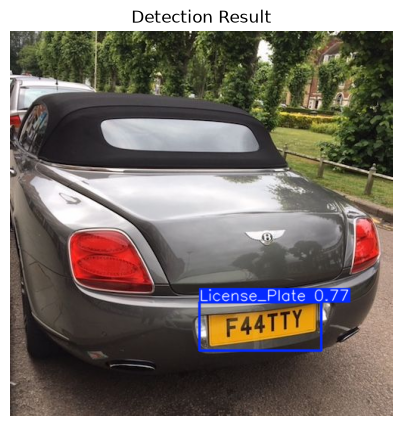

In [13]:
import matplotlib.pyplot as plt

IMAGE_PATH = r"C:\Users\PC\Downloads\d9827535c4959283e43906da670a6281.jpg"

results = model(IMAGE_PATH)
result_image = results[0].plot()

print("Shape of result image:", result_image.shape)  

plt.figure(figsize=(5, 5))
plt.imshow(result_image[:, :, ::-1])
plt.axis('off')
plt.title("Detection Result")
plt.show()

In [14]:
import cv2
import easyocr

In [17]:
reader = easyocr.Reader(['en'])

img = cv2.imread(IMAGE_PATH)

box = results[0].boxes[0]
x1, y1, x2, y2 = map(int, box.xyxy[0])
confidence = float(box.conf[0])

print(f"Plate coordinates: ({x1}, {y1}) -> ({x2}, {y2})")
print(f"Detection confidence: {confidence:.2f}")

plate_crop = img[y1:y2, x1:x2]
cv2.imwrite("plate_crop.jpg", plate_crop)
print("Cropped plate saved to plate_crop.jpg")

plate_crop_resized = cv2.resize(plate_crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
ocr_result = reader.readtext(plate_crop_resized, allowlist='0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')

print("\n--- OCR Result ---")
for (bbox, text, ocr_confidence) in ocr_result:
    print(f"Text: {text}  |  Confidence: {ocr_confidence:.2f}")

Plate coordinates: (250, 358) -> (411, 422)
Detection confidence: 0.77
Cropped plate saved to plate_crop.jpg

--- OCR Result ---
Text: F44TTY  |  Confidence: 0.99


In [27]:
import easyocr
from PIL import Image
import numpy as np

reader = easyocr.Reader(['en'])


img = Image.open(r"C:\Users\PC\Downloads\images_ocr\images (1).jpg").convert("RGB")
img_array = np.array(img)

results = reader.readtext(img_array)

for result in results:
    print("Detected Text:", result[1])
    print("Confidence:", result[2])
    

Detected Text: DL 7c0 1939
Confidence: 0.754914988130508


In [ ]:
import easyocr

reader = easyocr.Reader(['en'])

result = reader.readtext("")

for r in result:
    print("Plate Number:", r[1])

In [ ]:
import easyocr

reader = easyocr.Reader(['en'])

result = reader.readtext("/content/awhnug3ni3g21.jpg")

for r in result:
    print("Plate Number:", r[1])

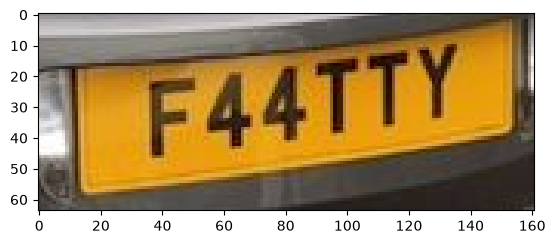

In [18]:
plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
plt.show()

In [19]:
def detect_and_read_plate(image_path):
    img = cv2.imread(image_path)
    results = model(img)
    
    if len(results[0].boxes) == 0:
        return {"status": "no_plate_found"}
    
    box = results[0].boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    detection_confidence = float(box.conf[0])
    
    plate_crop = img[y1:y2, x1:x2]
    plate_crop_resized = cv2.resize(plate_crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    
    ocr_result = reader.readtext(plate_crop_resized, allowlist='0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')
    
    if len(ocr_result) == 0:
        return {"status": "ocr_failed", "detection_confidence": detection_confidence}
    
    text = ocr_result[0][1]
    ocr_confidence = ocr_result[0][2]
    
    return {
        "status": "success",
        "plate_text": text,
        "detection_confidence": detection_confidence,
        "ocr_confidence": ocr_confidence
    }

In [20]:
result = detect_and_read_plate(r"C:\Users\PC\Downloads\d9827535c4959283e43906da670a6281.jpg")
print(result)



0: 640x640 1 License_Plate, 67.8ms
Speed: 458.1ms preprocess, 67.8ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
{'status': 'success', 'plate_text': 'F44TTY', 'detection_confidence': 0.7697411775588989, 'ocr_confidence': np.float64(0.9940266373976846)}


In [21]:
folder_path = r"C:\Users\PC\Downloads\images_ocr"

In [30]:
import os
import cv2
from ultralytics import YOLO
import easyocr

model = YOLO(r"D:\Smart Parking system\runs\detect\plate_detector-2\weights\best.pt")


reader = easyocr.Reader(['en'])

folder_path = r"C:\Users\PC\Downloads\images_ocr"

for filename in os.listdir(folder_path):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        full_path = os.path.join(folder_path, filename)

        img = cv2.imread(full_path)

        results = model.predict(img, conf=0.5)

        plate_number = "Not Detected"


        for box in results[0].boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            plate_crop = img[y1:y2, x1:x2]

            ocr_result = reader.readtext(plate_crop)

            if ocr_result:
                plate_number = " ".join([r[1] for r in ocr_result])

        print(f"{filename}: {plate_number}")


0: 640x640 1 License_Plate, 44.7ms
Speed: 8.9ms preprocess, 44.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
d9827535c4959283e43906da670a6281.jpg: F44tty

0: 416x640 1 License_Plate, 13.7ms
Speed: 2.0ms preprocess, 13.7ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 640)
images (1).jpg: DL 7c0 1939

0: 448x640 1 License_Plate, 13.9ms
Speed: 1.8ms preprocess, 13.9ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
images (3).jpg: EA0202A4

0: 448x640 1 License_Plate, 18.7ms
Speed: 1.9ms preprocess, 18.7ms inference, 6.1ms postprocess per image at shape (1, 3, 448, 640)
images (4).jpg: GX67 TKZ


In [1]:
from ultralytics import YOLO

model = YOLO(r"D:\Smart Parking system\runs\detect\occupancy_detector_v2\weights\best.pt")
print(model.names)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: 'object'}


In [2]:
{0: 'car', 1: 'empty', 2: 'motorcycle', 3: 'occupied', 4: 'space-empty', 5: 'space-occupied'}

{0: 'car',
 1: 'empty',
 2: 'motorcycle',
 3: 'occupied',
 4: 'space-empty',
 5: 'space-occupied'}

In [5]:
from ultralytics import YOLO
from collections import Counter

model = YOLO(r"D:\Smart Parking system\runs\detect\occupancy_detector_v2\weights\best.pt")
results = model.predict(r"C:\Users\PC\Downloads\images.jpg", conf=0.5)

class_ids = [int(box.cls[0]) for box in results[0].boxes]
print("Class distribution:", Counter(class_ids))


image 1/1 C:\Users\PC\Downloads\images.jpg: 480x640 7 3s, 8 4s, 13.4ms
Speed: 4.9ms preprocess, 13.4ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Class distribution: Counter({4: 8, 3: 7})
